# Initial Work

In [133]:
import pandas as pd
import numpy as np


In [134]:
target_column = ['First_Round_Interviews','Second_Round_Interviews','Offer_Received']

## Read the Data

In [135]:
df=pd.read_csv('../data/job_search_platform_efficacy_100k.csv')
df.head(20)

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN
5,STU_000006,Mid-tier,Large,Midwest,Business,4.00,0,4,1,Handshake,2,6,0,0,0,NaN,NaN,NaN,NaN,NaN
6,STU_000007,Top-tier,Large,West,STEM,3.28,2,0,7,Handshake,10,20,0,0,0,NaN,NaN,NaN,NaN,NaN
7,STU_000008,Lower-tier,Large,West,Business,2.62,2,3,7,LinkedIn,10,76,3,0,0,NaN,NaN,NaN,NaN,NaN
8,STU_000009,Mid-tier,Medium,Northeast,STEM,3.01,0,3,2,Handshake,7,19,2,1,1,31.0,69910.0,Mid-Size,7.0,1.0
9,STU_000010,Lower-tier,Medium,West,STEM,3.22,2,1,1,Indeed,6,67,2,1,1,38.0,73669.0,Startup,1.0,1.0


In [136]:
print(df.Accepted_Offer.value_counts(dropna=False))
print(df.Role_Relevance.value_counts(dropna=False))
print(df.Company_Size_Offered.value_counts(dropna=False))
print(df.Time_to_Offer_Days.value_counts(dropna=False))

Accepted_Offer
NaN    65771
1.0    27445
0.0     6784
Name: count, dtype: int64
Role_Relevance
NaN     65771
8.0      6500
7.0      5921
6.0      5038
9.0      4778
10.0     3744
5.0      3307
4.0      2115
3.0      1290
2.0       778
1.0       758
Name: count, dtype: int64
Company_Size_Offered
NaN           65771
Enterprise    13908
Mid-Size      13623
Startup        6698
Name: count, dtype: int64
Time_to_Offer_Days
NaN     65771
41.0      833
43.0      822
33.0      813
32.0      811
        ...  
14.0      201
19.0      200
16.0      193
17.0      184
18.0      183
Name: count, Length: 77, dtype: int64


## Data Cleaning

In [137]:
df_clean = df.drop(columns=['Student_ID','Offer_Salary','Company_Size_Offered','Role_Relevance','Accepted_Offer','Time_to_Offer_Days'])
df_clean.head(20)


,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
0,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1
1,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0
2,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0
3,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0
4,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0
5,Mid-tier,Large,Midwest,Business,4.00,0,4,1,Handshake,2,6,0,0,0
6,Top-tier,Large,West,STEM,3.28,2,0,7,Handshake,10,20,0,0,0
7,Lower-tier,Large,West,Business,2.62,2,3,7,LinkedIn,10,76,3,0,0
8,Mid-tier,Medium,Northeast,STEM,3.01,0,3,2,Handshake,7,19,2,1,1
9,Lower-tier,Medium,West,STEM,3.22,2,1,1,Indeed,6,67,2,1,1


In [138]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   University_Rating            100000 non-null  object 
 1   School_Size                  100000 non-null  object 
 2   Region                       100000 non-null  object 
 3   Major_Category               100000 non-null  object 
 4   GPA                          100000 non-null  float64
 5   Prior_Internships            100000 non-null  int64  
 6   Extra_Curricular_Activities  100000 non-null  int64  
 7   Networking_Events_Attended   100000 non-null  int64  
 8   Primary_Search_Platform      100000 non-null  object 
 9   Months_Searching             100000 non-null  int64  
 10  Applications_Submitted       100000 non-null  int64  
 11  First_Round_Interviews       100000 non-null  int64  
 12  Second_Round_Interviews      100000 non-null  int64  
 13  

In [139]:
print(df.duplicated().sum())
df_clean.describe()



0


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,3.196631,1.19697,2.003990,2.998600,6.499680,53.727620,2.16766,1.011640,0.342290
std,0.392370,1.12192,1.413709,1.734494,3.443719,45.004663,1.91176,1.138507,0.474478
min,2.000000,0.00000,0.000000,0.000000,1.000000,5.000000,0.00000,0.000000,0.000000
25%,2.930000,0.00000,1.000000,2.000000,4.000000,19.000000,1.00000,0.000000,0.000000
50%,3.200000,1.00000,2.000000,3.000000,6.000000,42.000000,2.00000,1.000000,0.000000
75%,3.470000,2.00000,3.000000,4.000000,9.000000,75.000000,3.00000,2.000000,1.000000
max,4.000000,5.00000,11.000000,14.000000,12.000000,300.000000,21.00000,12.000000,1.000000


## Preprocessing

### Create a 4-class Target Variable

> Created by Yueqiao


This will make it to a classification problem

In [140]:
def create_target(row):
    if row['Offer_Received'] == 1:
        return 3  # Got Offer
    elif row['Second_Round_Interviews'] > 0:
        return 2  # Second Round Interview but No Offer
    elif row['First_Round_Interviews'] > 0:
        return 1  # Interview but No Offer
    else:
        return 0  # No Interview
    
def return_target(num):
    if num == 3:
        return 'Got Offer'
    elif num == 2:
        return 'Second Round Interview but No Offer'
    elif num == 1:
        return 'Interview but No Offer'
    else:
        return 'No Interview'

df_clean['application_result'] = df_clean.apply(create_target, axis=1)
df_clean.drop(columns=target_column, inplace=True)
df_clean.head(2)

y = df_clean['application_result']
X = df_clean.drop(columns=['application_result'])

print("The distribution of the target variable:")
print(y.value_counts())

The distribution of the target variable:
application_result
3    34229
2    24543
1    20666
0    20562
Name: count, dtype: int64


### Divide to Numberic and Categorical
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [141]:
X_numeric = X.select_dtypes(include=[np.number])
print("Numeric columns:")
X_numeric_columns = X_numeric.columns
print(X_numeric.columns)
X_numeric.head(1)

Numeric columns:
Index(['GPA', 'Prior_Internships', 'Extra_Curricular_Activities',
       'Networking_Events_Attended', 'Months_Searching',
       'Applications_Submitted'],
      dtype='object')


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
0,2.81,3,2,6,1,9


In [142]:
X_categorical = X.select_dtypes(include=['object', 'string'])
print("\nCategorical columns:")
print(X_categorical.columns)
X_categorical.head(1)


Categorical columns:
Index(['University_Rating', 'School_Size', 'Region', 'Major_Category',
       'Primary_Search_Platform'],
      dtype='object')


,University_Rating,School_Size,Region,Major_Category,Primary_Search_Platform
0,Mid-tier,Medium,West,Healthcare,LinkedIn


### One Hot Encode Categorical Data
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [143]:
X_categorical_encoded = pd.get_dummies(X_categorical, drop_first=True)
X_categorical_encoded.head(1)

,University_Rating_Mid-tier,University_Rating_Top-tier,School_Size_Medium,School_Size_Small,Region_Northeast,Region_South,Region_West,Major_Category_Business,Major_Category_Healthcare,Major_Category_Humanities,Major_Category_STEM,Primary_Search_Platform_Indeed,Primary_Search_Platform_LinkedIn
0,True,False,True,False,False,False,True,False,True,False,False,False,True


### Train Test Split
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [144]:
from sklearn.model_selection import train_test_split
X_temp = pd.concat([X_numeric, X_categorical_encoded], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y, test_size=0.2, random_state=0)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (80000, 19)
Test set shape: (20000, 19)


### StandardScaler
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [145]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


X_train_numeric_scaled = scaler.fit_transform(X_train[X_numeric_columns])
X_test_numeric_scaled = scaler.transform(X_test[X_numeric_columns])


X_train_categorical = X_train.drop(columns=X_numeric_columns)
X_test_categorical = X_test.drop(columns=X_numeric_columns)

X_train = pd.concat([
    pd.DataFrame(X_train_numeric_scaled, columns=X_numeric_columns),
    X_train_categorical.reset_index(drop=True)
], axis=1)

X_test = pd.concat([
    pd.DataFrame(X_test_numeric_scaled, columns=X_numeric_columns),
    X_test_categorical.reset_index(drop=True)
], axis=1)


### Post-preprocessing Analysis
> Created by Yueqiao on May 1

In [146]:
print(X_train.shape)
print(X_test.shape)

(80000, 19)
(20000, 19)


In [147]:
X_train.head(1)

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,University_Rating_Mid-tier,University_Rating_Top-tier,School_Size_Medium,School_Size_Small,Region_Northeast,Region_South,Region_West,Major_Category_Business,Major_Category_Healthcare,Major_Category_Humanities,Major_Category_STEM,Primary_Search_Platform_Indeed,Primary_Search_Platform_LinkedIn
0,0.56821,1.608213,-0.708461,0.002156,-1.01732,-0.594424,True,False,True,False,False,False,False,False,False,False,True,True,False


In [148]:
X_train.describe()

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
count,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04
mean,1.950440e-16,-5.417888e-17,9.467982e-17,1.008971e-16,-1.101341e-16,4.387601e-17
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-3.052049e+00,-1.064847e+00,-1.416214e+00,-1.728705e+00,-1.598639e+00,-1.083425e+00
25%,-6.810343e-01,-1.064847e+00,-7.084608e-01,-5.747975e-01,-7.266599e-01,-7.722427e-01
50%,7.324971e-03,-1.738268e-01,-7.077531e-04,2.156365e-03,1.453189e-01,-2.610149e-01
75%,6.956842e-01,7.171931e-01,7.070453e-01,5.791103e-01,7.266381e-01,4.724859e-01
max,2.046908e+00,3.390253e+00,6.369070e+00,6.348649e+00,1.598617e+00,5.473628e+00


In [149]:
print("Class distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())



Class distribution in training set:
application_result
3    27410
2    19622
1    16488
0    16480
Name: count, dtype: int64

Class distribution in test set:
application_result
3    6819
2    4921
1    4178
0    4082
Name: count, dtype: int64


Text(0.5, 1.0, 'Target Distribution (Test Set)')

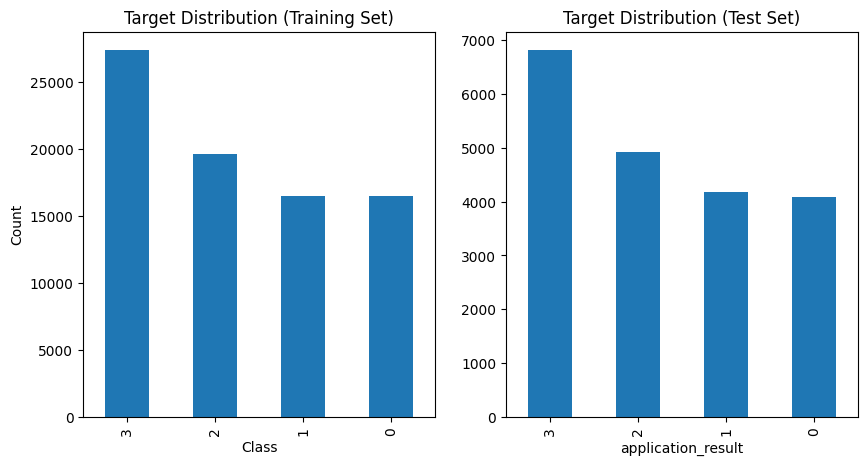

In [150]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar')
plt.title('Target Distribution (Training Set)')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind='bar')
plt.title('Target Distribution (Test Set)')

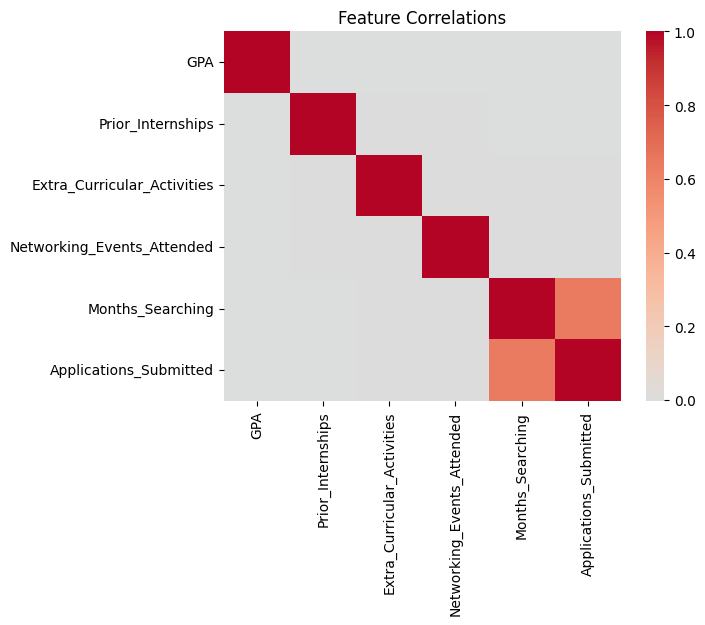

In [151]:

import seaborn as sns
sns.heatmap(X_numeric.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

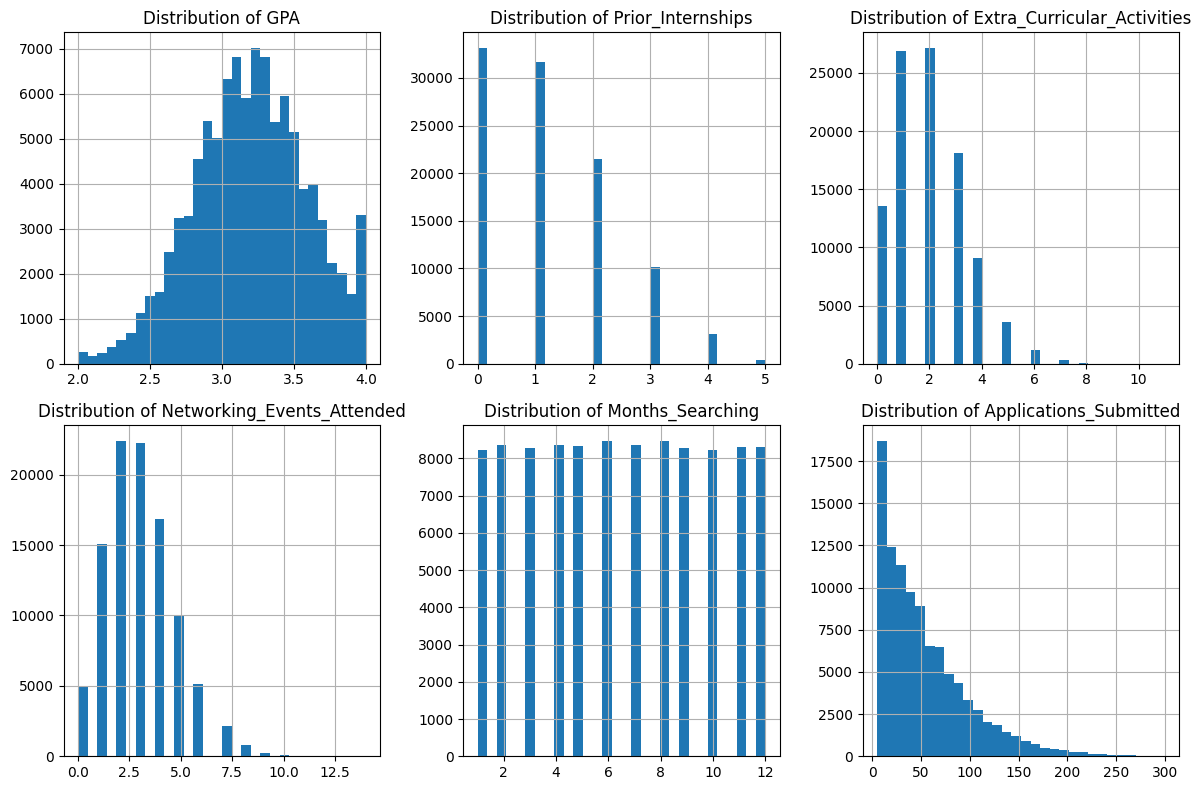

In [152]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, col in enumerate(X_numeric.columns):
    ax = axes[idx // 3, idx % 3]
    X_numeric[col].hist(bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## BaseLine
> Created by Yueqiao on Apr 30

In [153]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

### Most Frequent Class

In [154]:
most_frequent_class = y_train.value_counts().idxmax()
print(f"Most frequent class in training set: {return_target(most_frequent_class)}")
y_pred_baseline = np.full(len(y_test), most_frequent_class)
classification_rep = classification_report(y_test, y_pred_baseline)
print("Baseline Classification Report:")
print(classification_rep)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy (Most Frequent): {baseline_accuracy:.4f}")

Most frequent class in training set: Got Offer
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4082
           1       0.00      0.00      0.00      4178
           2       0.00      0.00      0.00      4921
           3       0.34      1.00      0.51      6819

    accuracy                           0.34     20000
   macro avg       0.09      0.25      0.13     20000
weighted avg       0.12      0.34      0.17     20000

Baseline Accuracy (Most Frequent): 0.3409


/Users/wyqwillsleep/Library/CloudStorage/OneDrive-Rose-HulmanInstituteofTechnology/Course/2026 Spring/MA 415/Final Project/Grp Try to get a Job - General/workspace/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/wyqwillsleep/Library/CloudStorage/OneDrive-Rose-HulmanInstituteofTechnology/Course/2026 Spring/MA 415/Final Project/Grp Try to get a Job - General/workspace/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/wyqwillsleep/Library/CloudStorage

## Initial Models
> Created by Yueqiao on Apr 30

### KNN Classifier

In [155]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
knn_classification_rep = classification_report(y_test, y_pred_knn)
print("KNN Classification Report:")
print(knn_classification_rep)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.48      0.43      4082
           1       0.24      0.25      0.24      4178
           2       0.35      0.35      0.35      4921
           3       0.43      0.36      0.39      6819

    accuracy                           0.36     20000
   macro avg       0.35      0.36      0.35     20000
weighted avg       0.36      0.36      0.36     20000

KNN Accuracy: 0.3593


### Simple Logistic Regression

In [156]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
logreg_classification_rep = classification_report(y_test, y_pred_logreg)
print("Logistic Regression Classification Report:")
print(logreg_classification_rep)
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {logreg_accuracy:.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.53      0.51      4082
           1       0.32      0.06      0.10      4178
           2       0.43      0.42      0.42      4921
           3       0.42      0.62      0.50      6819

    accuracy                           0.44     20000
   macro avg       0.42      0.41      0.38     20000
weighted avg       0.42      0.44      0.40     20000

Logistic Regression Accuracy: 0.4357


In [158]:
coef = logreg.coef_[0]
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coef
}).sort_values('coefficient', ascending=False)

print("Most important features (Logistic Regression):")
print(feature_importance.head(20))

Most important features (Logistic Regression):
                             feature  coefficient
17    Primary_Search_Platform_Indeed     1.936531
18  Primary_Search_Platform_LinkedIn     0.397706
13           Major_Category_Business     0.004841
9                  School_Size_Small     0.004749
3         Networking_Events_Attended    -0.001586
6         University_Rating_Mid-tier    -0.001845
2        Extra_Curricular_Activities    -0.002170
14         Major_Category_Healthcare    -0.007661
11                      Region_South    -0.011718
12                       Region_West    -0.012116
8                 School_Size_Medium    -0.012413
16               Major_Category_STEM    -0.015493
10                  Region_Northeast    -0.016503
15         Major_Category_Humanities    -0.020486
7         University_Rating_Top-tier    -0.031269
0                                GPA    -0.045953
1                  Prior_Internships    -0.114411
4                   Months_Searching    -0.201465
5  